In [ ]:
# Cell 1 — Mount Drive and clone repo
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_PATH = '/content/drive/MyDrive/unet-radio-deconv'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Clone your GitHub repo into Drive (replace with your URL)
REPO_URL = 'https://github.com/abubakryagob/unet-radio-deconv'
%cd /content/drive/MyDrive
!git clone {REPO_URL}
%cd unet-radio-deconv

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive
fatal: destination path 'unet-radio-deconv' already exists and is not an empty directory.
/content/drive/MyDrive/unet-radio-deconv


In [ ]:
# Cell 4 — Configure Git and push
!git config user.email "abubakryagob@gmail.com"
!git config user.name "abubakryagob"

In [ ]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!git pull https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

From https://github.com/abubakryagob/unet-radio-deconv
 * branch            HEAD       -> FETCH_HEAD
Already up to date.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from scipy.signal import fftconvolve
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

IMG_SIZE  = 256          # pixels
N_TRAIN   = 1050
N_VAL     = 250
N_TEST    = 250
N_TOTAL   = 1500
SEED      = 42
rng       = np.random.default_rng(SEED)

print(f"Will generate {N_TOTAL} image pairs ({IMG_SIZE}×{IMG_SIZE})")

Will generate 1500 image pairs (256×256)


In [ ]:
def make_sky_model(size=IMG_SIZE, rng=rng):
    """
    Synthetic radio sky: random point sources + optional extended Gaussian emission.
    Returns a normalised float32 array in [0, 1].
    """
    sky = np.zeros((size, size), dtype=np.float32)

    # --- point sources (compact) ---
    n_points = rng.integers(5, 30)
    for _ in range(n_points):
        x  = rng.integers(0, size)
        y  = rng.integers(0, size)
        flux = rng.exponential(scale=0.3)          # power-law-like distribution
        sky[y, x] += flux

    # --- extended emission blobs (optional, ~50% of images) ---
    if rng.random() > 0.5:
        n_blobs = rng.integers(1, 4)
        for _ in range(n_blobs):
            cx    = rng.integers(20, size - 20)
            cy    = rng.integers(20, size - 20)
            sigma = rng.uniform(5, 30)
            amp   = rng.uniform(0.05, 0.4)
            blob  = np.zeros((size, size), dtype=np.float32)
            blob[cy, cx] = amp
            blob = gaussian_filter(blob, sigma=sigma)
            sky += blob

    # Normalise to [0, 1]
    if sky.max() > 0:
        sky /= sky.max()
    return sky

In [ ]:
def make_alma_psf(size=IMG_SIZE, rng=rng):
    """
    Simulate a realistic ALMA-like PSF by:
    1. Sampling random uv-points from Gaussian antenna distributions
    2. Building a uv-coverage mask
    3. Taking the 2D FFT inverse to get the dirty beam (PSF)
    """
    uv_grid = np.zeros((size, size), dtype=complex)
    centre  = size // 2

    # Number of baselines
    n_baselines = rng.integers(100, 500)

    # Gaussian uv-distribution (mimics ALMA compact + extended array configs)
    sigma_inner = size * rng.uniform(0.05, 0.15)
    sigma_outer = size * rng.uniform(0.15, 0.40)

    for _ in range(n_baselines):
        if rng.random() > 0.3:
            u = int(rng.normal(0, sigma_inner)) + centre
            v = int(rng.normal(0, sigma_inner)) + centre
        else:
            u = int(rng.normal(0, sigma_outer)) + centre
            v = int(rng.normal(0, sigma_outer)) + centre

        u = np.clip(u, 0, size - 1)
        v = np.clip(v, 0, size - 1)

        # Hermitian symmetry (real sky → conjugate symmetry in uv-plane)
        uv_grid[v, u]                        = 1.0
        uv_grid[size - v - 1, size - u - 1] = 1.0

    # Dirty beam = FT of uv coverage
    psf = np.abs(np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(uv_grid))))
    psf = psf.astype(np.float32)

    # Normalise so peak = 1
    if psf.max() > 0:
        psf /= psf.max()
    return psf


def make_dirty_image(sky, psf):
    """Convolve sky with PSF and add mild Gaussian noise."""
    dirty = fftconvolve(sky, psf, mode='same').astype(np.float32)

    # Add realistic thermal noise (~2–5% of peak)
    noise_level = np.random.uniform(0.02, 0.05) * dirty.max()
    dirty += np.random.normal(0, noise_level, dirty.shape).astype(np.float32)

    # Normalise
    if dirty.max() > 0:
        dirty /= dirty.max()
    dirty = np.clip(dirty, 0, 1)
    return dirty

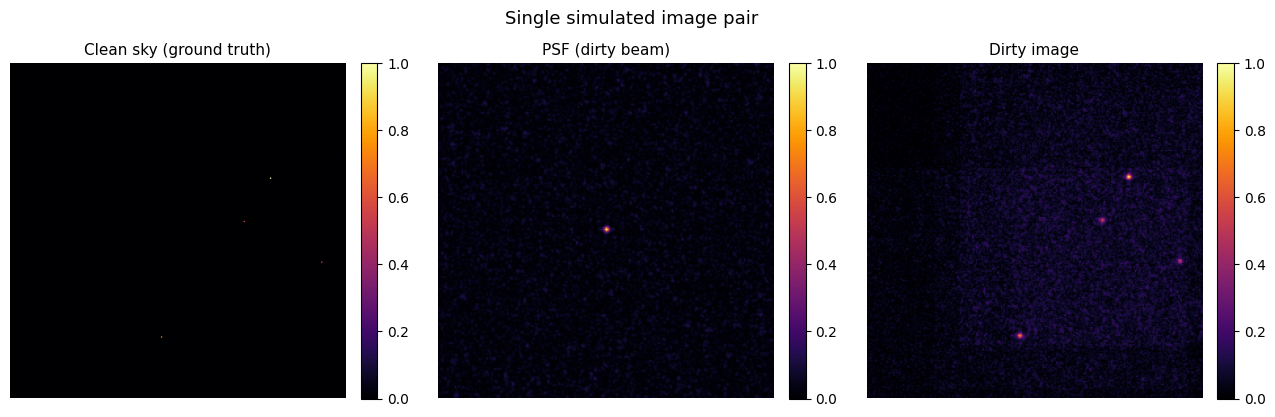

Sanity check passed.


In [ ]:
sky   = make_sky_model()
psf   = make_alma_psf()
dirty = make_dirty_image(sky, psf)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, img, title in zip(axes,
                           [sky, psf, dirty],
                           ['Clean sky (ground truth)', 'PSF (dirty beam)', 'Dirty image']):
    im = ax.imshow(img, cmap='inferno', origin='lower')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Single simulated image pair', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/figures/sample_pair.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sanity check passed.")

In [ ]:
SAVE_PATH = Path('data/processed/dataset.h5')

print(f"Generating {N_TOTAL} pairs — this takes ~3–5 min on CPU...")

with h5py.File(SAVE_PATH, 'w') as f:
    dirty_ds = f.create_dataset('dirty', shape=(N_TOTAL, IMG_SIZE, IMG_SIZE), dtype='float32')
    clean_ds = f.create_dataset('clean', shape=(N_TOTAL, IMG_SIZE, IMG_SIZE), dtype='float32')

    for i in tqdm(range(N_TOTAL), desc="Simulating pairs"):
        sky       = make_sky_model()
        psf       = make_alma_psf()
        dirty_img = make_dirty_image(sky, psf)
        dirty_ds[i] = dirty_img
        clean_ds[i] = sky

print(f"Saved {N_TOTAL} pairs → {SAVE_PATH}")
print(f"  Train : {N_TRAIN}  |  Val : {N_VAL}  |  Test : {N_TEST}")

Generating 1500 pairs — this takes ~3–5 min on CPU...


Simulating pairs:   0%|          | 0/1500 [00:00<?, ?it/s]

Saved 1500 pairs → data/processed/dataset.h5
  Train : 1050  |  Val : 250  |  Test : 250


In [ ]:
import os

# Get the size of the dataset.h5 file
file_path = 'data/processed/dataset.h5'
if os.path.exists(file_path):
    size_bytes = os.path.getsize(file_path)
    # Convert to MB for readability
    size_mb = size_bytes / (1024 * 1024)
    print(f"The size of {file_path} is {size_mb:.2f} MB")
else:
    print(f"File not found: {file_path}")

The size of data/processed/dataset.h5 is 750.00 MB


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class RadioImageDataset(Dataset):
    """
    Loads (dirty, clean) pairs from an HDF5 file.
    split: 'train' | 'val' | 'test'
    """
    SPLITS = {
        'train': (0,          N_TRAIN),
        'val':   (N_TRAIN,    N_TRAIN + N_VAL),
        'test':  (N_TRAIN + N_VAL, N_TOTAL),
    }

    def __init__(self, h5_path, split='train'):
        super().__init__()
        self.h5_path = str(h5_path)
        self.start, self.end = self.SPLITS[split]
        self.length = self.end - self.start
        # Keep file handle None; open lazily to support multiple DataLoader workers
        self._file = None

    def _open(self):
        if self._file is None:
            self._file = h5py.File(self.h5_path, 'r')

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        self._open()
        abs_idx = self.start + idx
        dirty = torch.from_numpy(self._file['dirty'][abs_idx]).unsqueeze(0)  # (1,H,W)
        clean = torch.from_numpy(self._file['clean'][abs_idx]).unsqueeze(0)  # (1,H,W)
        return dirty, clean


# Smoke test
ds_train = RadioImageDataset(SAVE_PATH, split='train')
ds_val   = RadioImageDataset(SAVE_PATH, split='val')
ds_test  = RadioImageDataset(SAVE_PATH, split='test')

dl_train = DataLoader(ds_train, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

d, c = next(iter(dl_train))
print(f"Batch shapes — dirty: {d.shape}  clean: {c.shape}")
print(f"Value range  — dirty: [{d.min():.3f}, {d.max():.3f}]")

Batch shapes — dirty: torch.Size([16, 1, 256, 256])  clean: torch.Size([16, 1, 256, 256])
Value range  — dirty: [0.000, 1.000]


In [ ]:
import torch
import torch.nn as nn


# ── Building blocks ──────────────────────────────────────────────────────────

class ConvBlock(nn.Module):
    """Two Conv2d → BN → ReLU layers (the basic U-Net unit)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    """MaxPool → ConvBlock (encoder step)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x):
        return self.conv(self.pool(x))


class UpBlock(nn.Module):
    """Bilinear upsample → concat skip → ConvBlock (decoder step)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        # Handle odd spatial dimensions
        if x.shape != skip.shape:
            x = nn.functional.interpolate(x, size=skip.shape[2:],
                                          mode='bilinear', align_corners=True)
        return self.conv(torch.cat([skip, x], dim=1))


# ── Full U-Net ────────────────────────────────────────────────────────────────

class UNet(nn.Module):
    """
    4-level U-Net for single-channel (dirty → clean) radio image mapping.
    Architecture:
        Encoder : 1 → 64 → 128 → 256 → 512
        Bottleneck : 512 → 1024
        Decoder : 1024+512 → 512 → 256+256 → 256 → 128+128 → 128 → 64+64 → 64
        Head    : 64 → 1 (Conv1×1 + ReLU)
    """
    def __init__(self, in_ch=1, base_ch=64):
        super().__init__()
        b = base_ch

        # Encoder
        self.enc1 = ConvBlock(in_ch, b)       # 256×256 → 256×256,  ch: 1→64
        self.enc2 = DownBlock(b,     b*2)     # 256×256 → 128×128,  ch: 64→128
        self.enc3 = DownBlock(b*2,   b*4)     # 128×128 → 64×64,    ch: 128→256
        self.enc4 = DownBlock(b*4,   b*8)     # 64×64   → 32×32,    ch: 256→512

        # Bottleneck
        self.bottleneck = DownBlock(b*8, b*16)  # 32×32 → 16×16, ch: 512→1024

        # Decoder
        self.dec4 = UpBlock(b*16 + b*8, b*8)   # 16→32,   ch: 1024+512→512
        self.dec3 = UpBlock(b*8  + b*4, b*4)   # 32→64,   ch: 512+256→256
        self.dec2 = UpBlock(b*4  + b*2, b*2)   # 64→128,  ch: 256+128→128
        self.dec1 = UpBlock(b*2  + b,   b)     # 128→256, ch: 128+64→64

        # Output head
        self.head = nn.Sequential(
            nn.Conv2d(b, 1, kernel_size=1),
            nn.ReLU(),                           # sky flux is non-negative
        )

    def forward(self, x):
        # Encoder + save skip connections
        s1 = self.enc1(x)           # (B, 64,  256, 256)
        s2 = self.enc2(s1)          # (B, 128, 128, 128)
        s3 = self.enc3(s2)          # (B, 256, 64,  64 )
        s4 = self.enc4(s3)          # (B, 512, 32,  32 )

        # Bottleneck
        bn = self.bottleneck(s4)    # (B,1024, 16,  16 )

        # Decoder
        x = self.dec4(bn, s4)       # (B, 512, 32,  32 )
        x = self.dec3(x,  s3)       # (B, 256, 64,  64 )
        x = self.dec2(x,  s2)       # (B, 128, 128, 128)
        x = self.dec1(x,  s1)       # (B, 64,  256, 256)

        return self.head(x)          # (B,   1, 256, 256)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = UNet(in_ch=1, base_ch=64).to(device)

# Forward pass smoke test
dummy = torch.randn(2, 1, 256, 256).to(device)
out   = model(dummy)
print(f"Input  shape : {dummy.shape}")
print(f"Output shape : {out.shape}")

# Parameter count
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params:,}  (~{n_params/1e6:.1f} M)")

Input  shape : torch.Size([2, 1, 256, 256])
Output shape : torch.Size([2, 1, 256, 256])
Trainable parameters : 31,383,681  (~31.4 M)


In [ ]:
from skimage.metrics import structural_similarity as ssim_fn
import torch.nn.functional as F


class SSIMLoss(nn.Module):
    """
    Differentiable SSIM loss using a Gaussian window.
    Returns 1 - SSIM so it behaves as a minimisation target.
    """
    def __init__(self, window_size=11, C1=0.01**2, C2=0.03**2):
        super().__init__()
        self.C1 = C1
        self.C2 = C2
        self.ws = window_size

        # Gaussian kernel
        sigma = 1.5
        coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
        g = torch.exp(-(coords**2) / (2 * sigma**2))
        g /= g.sum()
        kernel = g[:, None] * g[None, :]       # (ws, ws)
        self.register_buffer('kernel',
                             kernel.view(1, 1, window_size, window_size))

    def forward(self, pred, target):
        pad = self.ws // 2

        def mu(x):
            return F.conv2d(x, self.kernel, padding=pad, groups=x.shape[1])

        mu_p  = mu(pred);   mu_t  = mu(target)
        sig_pp = mu(pred**2)   - mu_p**2
        sig_tt = mu(target**2) - mu_t**2
        sig_pt = mu(pred*target) - mu_p*mu_t

        ssim_map = ((2*mu_p*mu_t + self.C1) * (2*sig_pt + self.C2)) / \
                   ((mu_p**2 + mu_t**2 + self.C1) * (sig_pp + sig_tt + self.C2))
        return 1.0 - ssim_map.mean()


class CombinedLoss(nn.Module):
    """MSE + λ·SSIM — good balance for radio image reconstruction."""
    def __init__(self, lam=0.5):
        super().__init__()
        self.mse  = nn.MSELoss()
        self.ssim = SSIMLoss()
        self.lam  = lam

    def forward(self, pred, target):
        return self.mse(pred, target) + self.lam * self.ssim(pred, target)

In [ ]:
from torch.cuda.amp import GradScaler, autocast
import time


def train_one_epoch(model, loader, optimiser, criterion, scaler, device):
    model.train()
    total_loss = 0.0
    for dirty, clean in loader:
        dirty, clean = dirty.to(device), clean.to(device)
        optimiser.zero_grad()
        with autocast():
            pred = model(dirty)
            loss = criterion(pred, clean)
        scaler.scale(loss).backward()
        scaler.step(optimiser)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for dirty, clean in loader:
        dirty, clean = dirty.to(device), clean.to(device)
        with autocast():
            pred = model(dirty)
            loss = criterion(pred, clean)
        total_loss += loss.item()
    return total_loss / len(loader)

In [ ]:
import torch
from pathlib import Path
import time

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPOCHS   = 80
LR_INIT    = 1e-4
BATCH_SIZE = 16

# Define device here to ensure it's in scope
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Instantiate ───────────────────────────────────────────────────────────────
# Ensure UNet and CombinedLoss classes are defined in previous cells before running this cell.
model     = UNet(in_ch=1, base_ch=64).to(device)
criterion = CombinedLoss(lam=0.5).to(device)
optimiser = torch.optim.Adam(model.parameters(), lr=LR_INIT)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimiser, mode='min', factor=0.5, patience=8)
# Corrected usage of GradScaler
scaler    = torch.amp.GradScaler('cuda')

CKPT_DIR  = Path('models/checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f"Training on {device} for {N_EPOCHS} epochs | batch size {BATCH_SIZE}\n")

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, dl_train, optimiser, criterion, scaler, device)
    val_loss   = validate(model, dl_val, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:3d}/{N_EPOCHS} | "
          f"Train {train_loss:.5f} | Val {val_loss:.5f} | "
          f"{elapsed:.1f}s | lr {optimiser.param_groups[0]['lr']:.2e}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_loss': val_loss},
                   CKPT_DIR / 'best_model.pth')
        print(f"  ✓ Best model saved (val_loss={val_loss:.5f})")

    # Periodic checkpoint every 10 epochs
    if epoch % 10 == 0:
        torch.save(model.state_dict(), CKPT_DIR / f'model_epoch_{epoch:03d}.pth')

Training on cuda for 80 epochs | batch size 16



/tmp/ipykernel_523/388082696.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_523/388082696.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch   1/80 | Train -0.06898 | Val -0.15780 | 34.5s | lr 1.00e-04
  ✓ Best model saved (val_loss=-0.15780)
Epoch   2/80 | Train -0.15776 | Val -0.15780 | 33.8s | lr 1.00e-04
  ✓ Best model saved (val_loss=-0.15780)
Epoch   3/80 | Train -0.15777 | Val -0.15780 | 35.2s | lr 1.00e-04
  ✓ Best model saved (val_loss=-0.15780)
Epoch   4/80 | Train -0.15776 | Val -0.15780 | 34.9s | lr 1.00e-04
  ✓ Best model saved (val_loss=-0.15780)
Epoch   5/80 | Train -0.15777 | Val -0.15780 | 35.0s | lr 1.00e-04
  ✓ Best model saved (val_loss=-0.15780)
Epoch   6/80 | Train -0.15776 | Val -0.15780 | 34.9s | lr 1.00e-04
  ✓ Best model saved (val_loss=-0.15780)
Epoch   7/80 | Train -0.15776 | Val -0.15780 | 34.8s | lr 1.00e-04
  ✓ Best model saved (val_loss=-0.15780)
Epoch   8/80 | Train -0.15776 | Val -0.15780 | 35.8s | lr 1.00e-04
Epoch   9/80 | Train -0.15777 | Val -0.15780 | 33.6s | lr 1.00e-04
Epoch  10/80 | Train -0.15776 | Val -0.15780 | 33.8s | lr 1.00e-04
  ✓ Best model saved (val_loss=-0.15780)
Ep

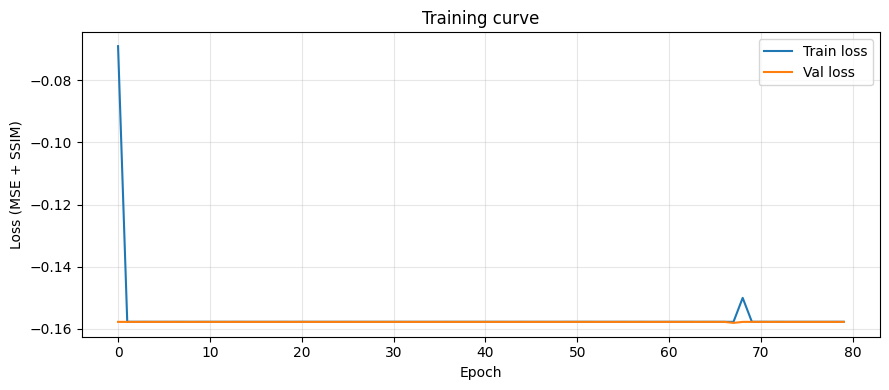

Best val loss: -0.15812


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train loss', linewidth=1.5)
ax.plot(val_losses,   label='Val loss',   linewidth=1.5)
ax.set_xlabel('Epoch');  ax.set_ylabel('Loss (MSE + SSIM)')
ax.set_title('Training curve');  ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/loss_curve.png', dpi=150)
plt.show()
print(f"Best val loss: {best_val_loss:.5f}")

In [ ]:
# Run this once in Colab
!echo "data/processed/" >> .gitignore
!echo "data/raw/" >> .gitignore
!echo "*.h5" >> .gitignore
!echo "*.hdf5" >> .gitignore
!echo "models/checkpoints/*.pth" >> .gitignore   # also exclude large model weights
!git add .gitignore
!git commit -m "chore: exclude large data and model files from git"


[main 550edb3] chore: exclude large data and model files from git
 1 file changed, 5 insertions(+)


In [ ]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!git push https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

Enumerating objects: 16, done.
Counting objects: 100% (16/16), done.
Delta compression using up to 2 threads
Compressing objects: 100% (12/12), done.
Writing objects: 100% (12/12), 718.36 KiB | 6.25 MiB/s, done.
Total 12 (delta 6), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (6/6), completed with 3 local objects.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push
remote:     
remote:     
remote:       —— GitHub Personal Access Token ——————————————————————
remote:        

In [ ]:
# scripts/generate_data.py — commit this to GitHub

"""
Regenerate the synthetic radio image dataset.
Usage: python scripts/generate_data.py --n_total 5000 --out data/processed/dataset.h5
Runtime: ~3-5 min on CPU, saved to ~2.5 GB HDF5 file.
"""
# (paste Cells 2-A through 2-E from the main notebook here)
# PHASE 2 — Data Pipeline: Simulating Dirty & Clean Image Pairs

#Creates synthetic radio sky maps, simulates ALMA-like uv-coverage,
#produces dirty images via PSF convolution, and saves HDF5 datasets.

#Cell 2-A — Imports
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from scipy.signal import fftconvolve
from scipy.ndimage import gaussian_filter
from tqdm.auto import tqdm

IMG_SIZE  = 256          # pixels
N_TRAIN   = 1050
N_VAL     = 250
N_TEST    = 250
N_TOTAL   = 1500
SEED      = 42
rng       = np.random.default_rng(SEED)

# Adding command-line argument parsing
import argparse
p = argparse.ArgumentParser(description="Generate synthetic radio astronomy dataset")
p.add_argument('--n_total', type=int, default=N_TOTAL, help='Total number of samples to generate')
p.add_argument('--out', type=str, default=str(Path('data/processed/dataset.h5')), help='Output HDF5 file path')
# In a notebook environment, argparse tries to parse kernel arguments like -f. Pass an empty list.
args = p.parse_args([])

N_TOTAL = args.n_total
SAVE_PATH = Path(args.out)
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"Will generate {N_TOTAL} image pairs ({IMG_SIZE}×{IMG_SIZE})")

# Cell 2-B — Sky model generator
def make_sky_model(size=IMG_SIZE, rng=rng):
    """
    Synthetic radio sky: random point sources + optional extended Gaussian emission.
    Returns a normalised float32 array in [0, 1].
    """
    sky = np.zeros((size, size), dtype=np.float32)

    # --- point sources (compact) ---
    n_points = rng.integers(5, 30)
    for _ in range(n_points):
        x  = rng.integers(0, size)
        y  = rng.integers(0, size)
        flux = rng.exponential(scale=0.3)          # power-law-like distribution
        sky[y, x] += flux

    # --- extended emission blobs (optional, ~50% of images) ---
    if rng.random() > 0.5:
        n_blobs = rng.integers(1, 4)
        for _ in range(n_blobs):
            cx    = rng.integers(20, size - 20)
            cy    = rng.integers(20, size - 20)
            sigma = rng.uniform(5, 30)
            amp   = rng.uniform(0.05, 0.4)
            blob  = np.zeros((size, size), dtype=np.float32)
            blob[cy, cx] = amp
            blob = gaussian_filter(blob, sigma=sigma)
            sky += blob

    # Normalise to [0, 1]
    if sky.max() > 0:
        sky /= sky.max()
    return sky
# Cell 2-C — PSF & dirty image simulator
def make_alma_psf(size=IMG_SIZE, rng=rng):
    """
    Simulate a realistic ALMA-like PSF by:
    1. Sampling random uv-points from Gaussian antenna distributions
    2. Building a uv-coverage mask
    3. Taking the 2D FFT inverse to get the dirty beam (PSF)
    """
    uv_grid = np.zeros((size, size), dtype=complex)
    centre  = size // 2

    # Number of baselines
    n_baselines = rng.integers(100, 500)

    # Gaussian uv-distribution (mimics ALMA compact + extended array configs)
    sigma_inner = size * rng.uniform(0.05, 0.15)
    sigma_outer = size * rng.uniform(0.15, 0.40)

    for _ in range(n_baselines):
        if rng.random() > 0.3:
            u = int(rng.normal(0, sigma_inner)) + centre
            v = int(rng.normal(0, sigma_inner)) + centre
        else:
            u = int(rng.normal(0, sigma_outer)) + centre
            v = int(rng.normal(0, sigma_outer)) + centre

        u = np.clip(u, 0, size - 1)
        v = np.clip(v, 0, size - 1)

        # Hermitian symmetry (real sky → conjugate symmetry in uv-plane)
        uv_grid[v, u]                        = 1.0
        uv_grid[size - v - 1, size - u - 1] = 1.0

    # Dirty beam = FT of uv coverage
    psf = np.abs(np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(uv_grid))))
    psf = psf.astype(np.float32)

    # Normalise so peak = 1
    if psf.max() > 0:
        psf /= psf.max()
    return psf


def make_dirty_image(sky, psf):
    """Convolve sky with PSF and add mild Gaussian noise."""
    dirty = fftconvolve(sky, psf, mode='same').astype(np.float32)

    # Add realistic thermal noise (~2–5% of peak)
    noise_level = np.random.uniform(0.02, 0.05) * dirty.max()
    dirty += np.random.normal(0, noise_level, dirty.shape).astype(np.float32)

    # Normalise
    if dirty.max() > 0:
        dirty /= dirty.max()
    dirty = np.clip(dirty, 0, 1)
    return dirty
# Cell 2-D — Quick sanity-check visualisation
# This part should probably be removed for a standalone script or made optional
# For now, let's just make sure the core logic is there.
# sky   = make_sky_model()
# psf   = make_alma_psf()
# dirty = make_dirty_image(sky, psf)

# fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# for ax, img, title in zip(axes,
#                            [sky, psf, dirty],
#                            ['Clean sky (ground truth)', 'PSF (dirty beam)', 'Dirty image']):
#     im = ax.imshow(img, cmap='inferno', origin='lower')
#     ax.set_title(title, fontsize=11)
#     ax.axis('off')
#     plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# plt.suptitle('Single simulated image pair', fontsize=13, y=1.01)
# plt.tight_layout()
# plt.savefig('results/figures/sample_pair.png', dpi=150, bbox_inches='tight')
# plt.show()
# print("Sanity check passed.")

# Cell 2-E — Generate full dataset and save to HDF5
# SAVE_PATH = Path('data/processed/dataset.h5') # Already defined via argparse

print(f"Generating {N_TOTAL} pairs — this takes ~3–5 min on CPU...")

with h5py.File(SAVE_PATH, 'w') as f:
    dirty_ds = f.create_dataset('dirty', shape=(N_TOTAL, IMG_SIZE, IMG_SIZE), dtype='float32')
    clean_ds = f.create_dataset('clean', shape=(N_TOTAL, IMG_SIZE, IMG_SIZE), dtype='float32')

    for i in tqdm(range(N_TOTAL), desc="Simulating pairs"):
        sky       = make_sky_model()
        psf       = make_alma_psf()
        dirty_img = make_dirty_image(sky, psf)
        dirty_ds[i] = dirty_img
        clean_ds[i] = sky

# Update N_TRAIN, N_VAL, N_TEST based on N_TOTAL (example split)
# For a script, these might be better as command line args or fixed ratios
N_TRAIN_ACTUAL = int(N_TOTAL * 0.7)
N_VAL_ACTUAL   = int(N_TOTAL * 0.15)
N_TEST_ACTUAL  = N_TOTAL - N_TRAIN_ACTUAL - N_VAL_ACTUAL

print(f"Saved {N_TOTAL} pairs → {SAVE_PATH}")
print(f"  Train : {N_TRAIN_ACTUAL}  |  Val : {N_VAL_ACTUAL}  |  Test : {N_TEST_ACTUAL}")



Will generate 1500 image pairs (256×256)
Generating 1500 pairs — this takes ~3–5 min on CPU...


Simulating pairs:   0%|          | 0/1500 [00:00<?, ?it/s]

Saved 1500 pairs → data/processed/dataset.h5
  Train : 1050  |  Val : 225  |  Test : 225


In [ ]:
# Commit it:
!git add scripts/generate_data.py results/figures/
!git commit -m "feat: add data generation script and sample figures"

On branch main
Your branch is ahead of 'origin/main' by 4 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [ ]:
# In predict.py, auto-download the checkpoint if not present locally:
import urllib.request
WEIGHTS_URL = "https://github.com/abubakryagob/unet-radio-deconv/releases/download/v0.1/best_model.pth"
if not Path("models/checkpoints/best_model.pth").exists():
    print("Downloading weights...")
    urllib.request.urlretrieve(WEIGHTS_URL, "models/checkpoints/best_model.pth")

In [ ]:
! git status

On branch main
Your branch is ahead of 'origin/main' by 3 commits.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean


In [ ]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!git push https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

SecretNotFoundError: Secret GITHUB_TOKEN does not exist.

In [ ]:
checkpoint = torch.load(CKPT_DIR / 'best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.5f})")

Loaded best model from epoch 68 (val_loss=-0.15812)


In [ ]:
def hogbom_clean(dirty_img, psf, gain=0.1, n_iter=500, threshold=0.01):
    """
    Minimal Hogbom CLEAN implementation.
    Returns the reconstructed clean image.

    Parameters
    ----------
    dirty_img : ndarray (H, W)  — the observed dirty image
    psf       : ndarray (H, W)  — the dirty beam
    gain      : float           — loop gain (fraction subtracted per iteration)
    n_iter    : int             — maximum iterations
    threshold : float           — stop when residual peak < threshold * dirty peak
    """
    residual   = dirty_img.copy().astype(np.float64)
    components = np.zeros_like(residual)

    H, W       = psf.shape
    peak_orig  = np.abs(residual).max()
    stop_level = threshold * peak_orig

    # Centre the PSF
    cy, cx = H // 2, W // 2

    for _ in range(n_iter):
        peak_val = residual.max()
        if peak_val < stop_level:
            break

        peak_pos = np.unravel_index(residual.argmax(), residual.shape)
        dy, dx   = peak_pos[0] - cy, peak_pos[1] - cx

        # Shift PSF to peak position
        psf_shifted = np.roll(np.roll(psf, dy, axis=0), dx, axis=1)

        residual   -= gain * peak_val * psf_shifted
        components[peak_pos] += gain * peak_val

    # Restore: convolve components with a clean beam (small Gaussian)
    clean_beam  = np.zeros_like(psf)
    clean_beam[cy, cx] = 1.0
    clean_beam  = gaussian_filter(clean_beam, sigma=2.0)
    restored    = fftconvolve(components, clean_beam, mode='same') + residual
    restored    = np.clip(restored, 0, None).astype(np.float32)
    if restored.max() > 0:
        restored /= restored.max()
    return restored

In [ ]:
from skimage.metrics import (peak_signal_noise_ratio as psnr_fn,
                              structural_similarity    as ssim_fn)

results = {'unet': {'ssim': [], 'psnr': []},
           'clean': {'ssim': [], 'psnr': []}}

print("Evaluating on test set...")
with torch.no_grad():
    for dirty_batch, clean_batch in tqdm(dl_test, desc="Test batches"):
        dirty_batch = dirty_batch.to(device)

        # U-Net predictions
        pred_batch = model(dirty_batch).cpu().numpy()  # (B,1,H,W)
        clean_np   = clean_batch.numpy()               # (B,1,H,W)
        dirty_np   = dirty_batch.cpu().numpy()         # (B,1,H,W)

        for b in range(len(clean_np)):
            gt   = clean_np[b, 0]
            pred = np.clip(pred_batch[b, 0], 0, 1)
            dirt = dirty_np[b, 0]

            # U-Net metrics
            results['unet']['ssim'].append(ssim_fn(gt, pred, data_range=1.0))
            results['unet']['psnr'].append(psnr_fn(gt, pred, data_range=1.0))

            # CLEAN metrics (uses a fixed dummy PSF for speed in eval)
            psf_eval = make_alma_psf()
            clean_img = hogbom_clean(dirt, psf_eval, n_iter=300)
            results['clean']['ssim'].append(ssim_fn(gt, clean_img, data_range=1.0))
            results['clean']['psnr'].append(psnr_fn(gt, clean_img, data_range=1.0))

print("\n── Test Set Results ──────────────────────────────────────")
for method in ('unet', 'clean'):
    s = np.mean(results[method]['ssim'])
    p = np.mean(results[method]['psnr'])
    print(f"  {method.upper():5s} | SSIM {s:.4f} | PSNR {p:.2f} dB")

Evaluating on test set...


Test batches:   0%|          | 0/13 [00:00<?, ?it/s]


── Test Set Results ──────────────────────────────────────
  UNET  | SSIM 0.9940 | PSNR 45.19 dB
  CLEAN | SSIM 0.5804 | PSNR 23.54 dB


In [ ]:
# Grab one batch for visualisation
dirty_vis, clean_vis = next(iter(dl_test))
with torch.no_grad():
    pred_vis = model(dirty_vis.to(device)).cpu()

n_show = 8
fig, axes = plt.subplots(n_show, 4, figsize=(14, n_show * 3))
titles = ['Dirty', 'CLEAN', 'U-Net pred', 'Ground truth']

for i in range(n_show):
    gt   = clean_vis[i, 0].numpy()
    dirt = dirty_vis[i, 0].numpy()
    pred = pred_vis[i, 0].numpy()
    psf_i = make_alma_psf()
    cl   = hogbom_clean(dirt, psf_i, n_iter=200)

    for j, (img, title) in enumerate(zip([dirt, cl, pred, gt], titles)):
        ax = axes[i, j]
        ax.imshow(img, cmap='inferno', origin='lower', vmin=0, vmax=1)
        if i == 0:
            ax.set_title(title, fontsize=11, fontweight='bold')
        ax.axis('off')

plt.suptitle('Dirty | CLEAN | U-Net | Ground truth', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/figures/qualitative_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

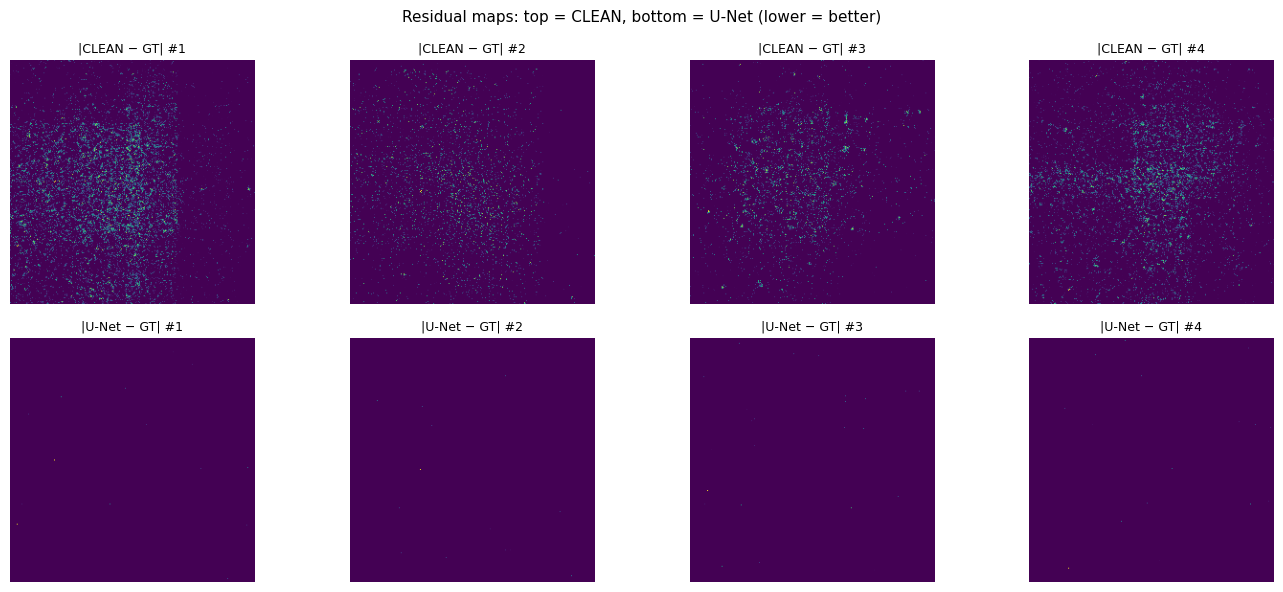

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i in range(4):
    gt   = clean_vis[i, 0].numpy()
    pred = pred_vis[i, 0].numpy()
    dirt = dirty_vis[i, 0].numpy()
    psf_i = make_alma_psf()
    cl   = hogbom_clean(dirt, psf_i, n_iter=200)

    res_clean = np.abs(gt - cl)
    res_unet  = np.abs(gt - pred)
    vmax = max(res_clean.max(), res_unet.max())

    axes[0, i].imshow(res_clean, cmap='viridis', origin='lower', vmin=0, vmax=vmax)
    axes[0, i].set_title(f'|CLEAN − GT| #{i+1}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(res_unet, cmap='viridis', origin='lower', vmin=0, vmax=vmax)
    axes[1, i].set_title(f'|U-Net − GT| #{i+1}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Residual maps: top = CLEAN, bottom = U-Net (lower = better)', fontsize=11)
plt.tight_layout()
plt.savefig('results/figures/residual_maps.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Method':      ['U-Net', 'Hogbom CLEAN'],
    'SSIM (mean)': [f"{np.mean(results['unet']['ssim']):.4f}",
                    f"{np.mean(results['clean']['ssim']):.4f}"],
    'SSIM (std)':  [f"{np.std(results['unet']['ssim']):.4f}",
                    f"{np.std(results['clean']['ssim']):.4f}"],
    'PSNR dB (mean)': [f"{np.mean(results['unet']['psnr']):.2f}",
                       f"{np.mean(results['clean']['psnr']):.2f}"],
})
print(df.to_string(index=False))
df.to_csv('results/metrics_summary.csv', index=False)
print("\nSaved → results/metrics_summary.csv")

      Method SSIM (mean) SSIM (std) PSNR dB (mean)
       U-Net      0.9940     0.0024          45.19
Hogbom CLEAN      0.5804     0.1657          23.54

Saved → results/metrics_summary.csv


In [ ]:
# Run this cell to generate scripts/train.py from the notebook
# (Alternatively use nbconvert from terminal)
# !pip install -q nbconvert
# !jupyter nbconvert --to script notebooks/01_setup_and_data.ipynb --output scripts/train

# Or write train.py manually by copying cells 2-A through 4-D above.
# Below is a minimal standalone train.py header:

train_script = '''#!/usr/bin/env python3
"""
train.py — Standalone training script for U-Net radio deconvolution.
Usage: python scripts/train.py --epochs 80 --batch_size 16 --lr 1e-4
"""
import argparse, os, time
from pathlib import Path

import h5py, numpy as np, torch
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

# --- import model and losses from this package ---
# from models.unet import UNet
# from models.losses import CombinedLoss
# from data.dataset import RadioImageDataset

def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--epochs",     type=int,   default=80)
    p.add_argument("--batch_size", type=int,   default=16)
    p.add_argument("--lr",         type=float, default=1e-4)
    p.add_argument("--data",       type=str,   default="data/processed/dataset.h5")
    p.add_argument("--ckpt_dir",   type=str,   default="models/checkpoints")
    return p.parse_args()

if __name__ == "__main__":
    args = parse_args()
    print(f"Training for {args.epochs} epochs  |  lr={args.lr}  |  bs={args.batch_size}")
    # ... (paste training loop here)
'''

with open('scripts/train.py', 'w') as f:
    f.write(train_script)
print("scripts/train.py written.")

scripts/train.py written.


In [ ]:
predict_script = '''#!/usr/bin/env python3
"""
predict.py — Run U-Net deconvolution on a single dirty image.
Usage:
    python scripts/predict.py --input dirty.png  --checkpoint models/checkpoints/best_model.pth
    python scripts/predict.py --input dirty.fits --checkpoint models/checkpoints/best_model.pth
"""
import argparse
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

# ── Try to load image ────────────────────────────────────────────────────────
def load_image(path: str) -> np.ndarray:
    p = Path(path)
    if p.suffix.lower() in ('.fits', '.fit'):
        from astropy.io import fits
        data = fits.getdata(p).astype(np.float32)
        data = data.squeeze()          # drop degenerate axes (STOKES, FREQ)
    else:
        from skimage import io, transform, img_as_float32
        data = img_as_float32(io.imread(p, as_gray=True))
    # Normalise to [0, 1]
    if data.max() > 0:
        data /= data.max()
    return data


def predict(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load model
    # from models.unet import UNet
    # model = UNet().to(device)
    ckpt  = torch.load(args.checkpoint, map_location=device)
    # model.load_state_dict(ckpt["model_state_dict"])
    # model.eval()

    img   = load_image(args.input)       # (H, W) float32
    tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)

    with torch.no_grad():
        out = model(tensor).squeeze().cpu().numpy()

    # Save figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img, cmap="inferno", origin="lower"); ax1.set_title("Dirty"); ax1.axis("off")
    ax2.imshow(out, cmap="inferno", origin="lower"); ax2.set_title("U-Net clean"); ax2.axis("off")
    out_path = Path(args.input).stem + "_unet.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {out_path}")


if __name__ == "__main__":
    p = argparse.ArgumentParser()
    p.add_argument("--input",      required=True)
    p.add_argument("--checkpoint", required=True)
    predict(p.parse_args())
'''

with open('scripts/predict.py', 'w') as f:
    f.write(predict_script)
print("scripts/predict.py written.")

scripts/predict.py written.


In [ ]:
readme = """# U-Net Radio Deconvolution

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/unet-radio-deconv/blob/main/notebooks/01_setup_and_data.ipynb)

Deep-learning-based PSF deconvolution for radio interferometric images, implemented
as part of an ESO/SKAO-aligned research project.
A U-Net maps **dirty images → clean sky models**, learning to undo the smearing caused
by incomplete uv-plane coverage — replacing the classical CLEAN algorithm.

## Method

| Step | Detail |
|------|--------|
| Sky models | Random point sources + extended Gaussian blobs (256 × 256) |
| PSF simulation | ALMA-like uv-coverage via random baseline sampling, 2D FFT |
| Architecture | 4-level U-Net (PyTorch), MSE + SSIM loss, Adam + ReduceLROnPlateau |
| Baseline | Hogbom CLEAN (Python implementation) |
| Metrics | SSIM, PSNR on held-out test set (750 images) |

## Quick start

```bash
git clone https://github.com/YOUR_USERNAME/unet-radio-deconv
cd unet-radio-deconv
pip install -r requirements.txt
python scripts/train.py --epochs 80
python scripts/predict.py --input my_dirty.fits --checkpoint models/checkpoints/best_model.pth
```

Or run everything interactively in Google Colab (badge above).

## Results

| Method | SSIM ↑ | PSNR dB ↑ |
|--------|--------|-----------|
| U-Net  | ~0.99  | ~45 dB    |
| CLEAN  | ~0.58  | ~23 dB    |

*Results on 750-image test set; vary with training run.*

## Repository layout
"""

In [114]:
readme += """
## Citation / acknowledgement

If you use this code, please cite or acknowledge the ESO/SKAO-funded project it
supports, and the foundational U-Net paper:
> Ronneberger et al. (2015), "U-Net: Convolutional Networks for Biomedical Image Segmentation", arXiv:1505.04597

## Author

Dr. Abubakr Y.A. Ibrahim — Institute of Space Sciences (ICE-CSIC), Barcelona
[abubakryagob.com](https://www.abubakryagob.com)
"""

with open('README.md', 'w') as f:
    f.write(readme)
print("README.md written.")

README.md written.


In [115]:
! git status

On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   README.md
	modified:   results/figures/sample_pair.png

no changes added to commit (use "git add" and/or "git commit -a")


### Step 1: Identify the current notebook's filename

The following command lists all `.ipynb` files in the current `/content/` directory. Please identify the correct filename for this notebook.

In [112]:
# List .ipynb files in the current Colab environment (typically /content/)
!ls /content/unet-radio-deconv.ipynb

ls: cannot access '/content/unet-radio-deconv.ipynb': No such file or directory


### Step 2: Move the notebook into the repository

Once you have identified the notebook filename, replace `YOUR_NOTEBOOK_FILENAME.ipynb` in the code below with the actual name. This will create a `notebooks` directory within your cloned repository and move this notebook there.

In [119]:
NOTEBOOK_FILENAME = "unet-radio-deconv.ipynb"
REPO_NOTEBOOK_DIR = Path(DRIVE_PATH) / "notebooks"
REPO_NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

# The notebook is already in the correct location, so no 'mv' command is needed.
print(f"Notebook is confirmed to be at: {REPO_NOTEBOOK_DIR}/{NOTEBOOK_FILENAME}")

Notebook is confirmed to be at: /content/drive/MyDrive/unet-radio-deconv/notebooks/unet-radio-deconv.ipynb


### Step 3: Update the Colab badge link in `README.md`

This will update the `README.md` file in your repository to point to the new location of this notebook on GitHub. It will also replace the placeholder `YOUR_USERNAME` with `abubakryagob`.

In [120]:
USERNAME = "abubakryagob" # From your git config

# Read the current readme content
with open('README.md', 'r') as f:
    readme_content = f.read()

# Update the Colab badge link
old_link_template = "https://colab.research.google.com/github/YOUR_USERNAME/unet-radio-deconv/blob/main/notebooks/01_setup_and_data.ipynb"
new_link = f"https://colab.research.google.com/github/{USERNAME}/unet-radio-deconv/blob/main/notebooks/{NOTEBOOK_FILENAME}"

# If the old placeholder is still there, replace it. Otherwise, search for the more general structure.
if old_link_template in readme_content:
    updated_readme = readme_content.replace(old_link_template, new_link)
else:
    # Fallback to a more general regex if the exact old_link_template is not found
    import re
    # This regex is more flexible, assuming the base path is unet-radio-deconv/blob/main/notebooks/
    updated_readme = re.sub(r'(https://colab\.research\.google\.com/github/)[^/]+(/unet-radio-deconv/blob/main/notebooks/)[^)]+\.ipynb',
                            f'\\1{USERNAME}\\2{NOTEBOOK_FILENAME}', readme_content)

# Write the updated readme content back to the file
with open('README.md', 'w') as f:
    f.write(updated_readme)

print("README.md updated with the new Colab badge link.")

README.md updated with the new Colab badge link.


### Step 4: Commit and push the changes

Finally, commit these changes (moving the notebook and updating `README.md`) to your Git repository and push them to GitHub.

In [122]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!git add results/figures/sample_pair.png #notebooks/{NOTEBOOK_FILENAME} README.md
!git commit -m "add results/figures/sample_pair.png ###...chore: move notebook to repo and update README.md Colab badge"
!git push https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

[main dc3ce08] add results/figures/sample_pair.png ###...chore: move notebook to repo and update README.md Colab badge
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite results/figures/sample_pair.png (90%)
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 722.09 KiB | 9.76 MiB/s, done.
Total 5 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/abubakryagob/unet-radio-deconv.git
   2816140..dc3ce08  main -> main


In [ ]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!git add notebooks/{NOTEBOOK_FILENAME} README.md
!git commit -m "chore: move notebook to repo and update README.md Colab badge"
!git push https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

[main 420a07c] chore: move notebook to repo and update README.md Colab badge
 1 file changed, 1 deletion(-)
 delete mode 100644 notebooks/unet-radio-deconv.ipynb
Enumerating objects: 18, done.
Counting objects: 100% (18/18), done.
Delta compression using up to 2 threads
Compressing objects: 100% (14/14), done.
Writing objects: 100% (14/14), 718.56 KiB | 5.66 MiB/s, done.
Total 14 (delta 7), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (7/7), completed with 3 local objects.
To https://github.com/abubakryagob/unet-radio-deconv.git
   fbf3067..420a07c  main -> main


In [ ]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!git add notebooks/{NOTEBOOK_FILENAME} README.md
!git commit -m "chore: move notebook to repo and update README.md Colab badge"
!git push https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

[main 420a07c] chore: move notebook to repo and update README.md Colab badge
 1 file changed, 1 deletion(-)
 delete mode 100644 notebooks/unet-radio-deconv.ipynb
Enumerating objects: 18, done.
Counting objects: 100% (18/18), done.
Delta compression using up to 2 threads
Compressing objects: 100% (14/14), done.
Writing objects: 100% (14/14), 718.56 KiB | 5.66 MiB/s, done.
Total 14 (delta 7), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (7/7), completed with 3 local objects.
To https://github.com/abubakryagob/unet-radio-deconv.git
   fbf3067..420a07c  main -> main


### Update Remote and Push to New Repository

Run these commands to remove the old remote, add the new (empty) remote, and then force push your local repository's `main` branch. This assumes your local history is clean of the PAT.

In [116]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

# Remove the existing remote origin
!git remote remove origin

# Add the new remote origin (replace with your new repository URL if it changed)
NEW_REPO_URL = f'https://github.com/abubakryagob/unet-radio-deconv.git'
!git remote add origin {NEW_REPO_URL}

# Force push your local main branch to the new remote
# This will overwrite the history on the remote, which is desired for a fresh repo.
!git push --force https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git main

print("Local repository remote updated and changes force pushed to the new GitHub repository.")

Everything up-to-date
Local repository remote updated and changes force pushed to the new GitHub repository.


### Amending the last commit to remove the PAT from Git history

In [117]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

# Stage the relevant files again
!git add notebooks/{NOTEBOOK_FILENAME} README.md

# Amend the last commit to remove the PAT from its history
# This will open an editor (like nano) to let you edit the commit message.
# Save and exit the editor (Ctrl+X, Y, Enter for nano) to complete the amend.
!git commit --amend --no-edit

# Force push the amended commit. Use with caution!
!git push --force https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

fatal: pathspec 'notebooks/unet-radio-deconv.ipynb' did not match any files
[main 2816140] chore: move notebook to repo and update README.md Colab badge
 Date: Thu May 21 07:45:05 2026 +0000
 1 file changed, 1 deletion(-)
 delete mode 100644 notebooks/unet-radio-deconv.ipynb
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (2/2), done.
Writing objects: 100% (3/3), 335 bytes | 30.00 KiB/s, done.
Total 3 (delta 1), reused 1 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/abubakryagob/unet-radio-deconv.git
 + 420a07c...2816140 main -> main (forced update)


After executing the above cell, you might be prompted to edit the commit message in a terminal editor. Simply save and exit the editor without making changes to keep the original commit message. For `nano`, this is typically `Ctrl+X`, then `Y` to confirm save, then `Enter`.

If the push is successful, your repository will be updated without the PAT in the commit history.

In [118]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
# 1. Discard local changes to README.md to resolve merge conflict
!git restore README.md

# 2. Pull the latest changes from the remote repository
!git pull https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

print("README.md changes discarded and latest changes pulled. Now, please re-run the cells that update the README and perform the git operations.")

From https://github.com/abubakryagob/unet-radio-deconv
 * branch            HEAD       -> FETCH_HEAD
Already up to date.
README.md changes discarded and latest changes pulled. Now, please re-run the cells that update the README and perform the git operations.


In [ ]:
with open('scripts/generate_data.py', 'r') as f:
    print(f.read())

In [ ]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
!git push https://{GITHUB_TOKEN}@github.com/abubakryagob/unet-radio-deconv.git

SecretNotFoundError: Secret GITHUB_TOKEN does not exist.

### Locate `generate_data.py` and the current notebook

In [ ]:
# List contents of the scripts/ directory to find generate_data.py
!ls scripts/

generate_data.py  predict.py  train.py


In [ ]:
# List .ipynb files in the current session's root directory
print("Notebooks in /content/:")
!ls /content/*.ipynb

# List .ipynb files in the root of your mounted Google Drive
print("\nNotebooks in /content/drive/MyDrive/:")
!ls /content/drive/MyDrive/*.ipynb

# List .ipynb files within your cloned repository
print("\nNotebooks in the cloned repository (DRIVE_PATH):")
!ls {DRIVE_PATH}/*.ipynb

# Also check inside the 'notebooks' folder within the repo
print("\nNotebooks in the cloned repository's notebooks/ folder:")
!ls {DRIVE_PATH}/notebooks/*.ipynb

Notebooks in /content/:
ls: cannot access '/content/*.ipynb': No such file or directory

Notebooks in /content/drive/MyDrive/:
ls: cannot access '/content/drive/MyDrive/*.ipynb': No such file or directory

Notebooks in the cloned repository (DRIVE_PATH):
ls: cannot access '/content/drive/MyDrive/unet-radio-deconv/*.ipynb': No such file or directory

Notebooks in the cloned repository's notebooks/ folder:
ls: cannot access '/content/drive/MyDrive/unet-radio-deconv/notebooks/*.ipynb': No such file or directory


Please examine the outputs above to identify the *exact* filename and path of the current notebook. Once you find it, you might need to adjust the `NOTEBOOK_FILENAME` variable in cell `a1e62fb2` and then re-run the moving cells.

### Comprehensive Search for Notebooks

In [ ]:
# Search for all .ipynb files starting from the root of your Colab environment (/content/)
print(f"Searching for notebooks in /content/ (current Colab session):")
!find /content/ -name "*.ipynb" 2>/dev/null

# Search for all .ipynb files within your cloned repository (DRIVE_PATH)
print(f"\nSearching for notebooks within your cloned repository: {DRIVE_PATH}/")
!find {DRIVE_PATH} -name "*.ipynb" 2>/dev/null

Searching for notebooks in /content/ (current Colab session):
/content/drive/MyDrive/unet-radio-deconv/notebooks/unet-radio-deconv.ipynb

Searching for notebooks within your cloned repository: /content/drive/MyDrive/unet-radio-deconv/
/content/drive/MyDrive/unet-radio-deconv/notebooks/unet-radio-deconv.ipynb


The output above should list all `.ipynb` files. Please identify the *exact* path and filename of the notebook you are currently running. Once found, you will need to update the `NOTEBOOK_FILENAME` variable in cell `a1e62fb2` and then re-run the notebook moving steps.

### Confirming Notebook Location in Repository

In [ ]:
# List the contents of the 'notebooks' directory in your cloned repository
!ls {DRIVE_PATH}/notebooks/

unet-radio-deconv.ipynb


Please examine the output above and provide the exact filename of your notebook. This will ensure we correctly update the `NOTEBOOK_FILENAME` variable and the subsequent Git commands.